# HI Window Function: Pipeline vs Pinetti (2022) Thesis

This notebook compares the pipeline's HI window function against a **standalone reimplementation faithful to Pinetti (2022)** thesis choices. The pipeline has several deliberate deviations from the thesis; this notebook quantifies their individual and combined effects.

| # | Parameter | Pipeline | Pinetti (2022) |
|---|-----------|----------|----------------|
| 1 | $\Delta_\text{vir}$ | Bryan & Norman $\Delta(z)$ | Bryan & Norman $\Delta(z)$ |
| 2 | SMT $q$ | 0.707 (SMT 1999) | **0.75** (ST 2002) |
| 3 | $\Omega_\text{HI}$ | Computed from halo integral | **Fixed $2.45 \times 10^{-4}$** |
| 4 | Correa $c(M,z)$ coefficients | Planck Appendix B1 | **Thesis-specific fit** |
| 5 | Limber $k$-substitution | $k = (\ell+1/2)/\chi$ | **$k = \ell/\chi$** |
| 6 | $\bar{T}_b$ coefficient | $188h$ mK | **$44\,\mu$K pre-evaluated** |
| 7 | $c_\text{HI}$ mass pivot | $M_\odot$ (with $h$-conversion) | $M_\odot$ (with $h$-conversion) |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

from hi_gamma_xcorr import (
    config as cfg, cosmology as cosmo, halo_model as hm,
    hmf_interface as hmfi, hi_model as hi, angular_power as ap,
    pinetti2022 as p22,
)

cosmo.init()
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Pinetti (2022) Standalone Functions

Reimplementation of the HI window function chain using thesis-specific choices.

In [2]:
# All Pinetti (2022) thesis-specific overrides are now provided by the
# pinetti2022 module. No inline reimplementation needed.
#
# Available functions:
#   p22.T_bar_b_thesis(z)              — 44 muK brightness temperature
#   p22.bias_pinetti(M, z)             — q=0.75 Sheth-Tormen bias
#   p22.b_HI_pinetti(z)               — HI bias with q=0.75
#   p22.W_HI_pinetti(z, z_min, z_max) — full HI window (thesis-faithful)
#   p22.concentration_correa_thesis(M, z) — thesis Correa coefficients
#   p22.limber_k(ell, chi)             — k = ell/chi (no +0.5)
#
# Constants: p22.PINETTI_Q, p22.PINETTI_OMEGA_HI, p22.PINETTI_T_B_MK
# Registry:  p22.DEVIATIONS

print("Pinetti (2022) module loaded.")
print(f"  Deviations tracked: {list(p22.DEVIATIONS.keys())}")
print(f"  q = {p22.PINETTI_Q} (pipeline: {cfg.SMT_Q})")
print(f"  Omega_HI = {p22.PINETTI_OMEGA_HI} (pipeline: computed)")
print(f"  T_b coeff = {p22.PINETTI_T_B_MK} mK (pipeline: 188*h = {188*cfg.h:.1f} mK * Omega_HI)")

Pinetti (2022) module loaded.
  Deviations tracked: ['smt_q', 'omega_hi', 'correa_coeffs', 'limber_k', 'T_b_form', 'pppc4dmid', 'sfg_kr2_sign']
  q = 0.75 (pipeline: 0.707)
  Omega_HI = 0.000245 (pipeline: computed)
  T_b coeff = 0.044 mK (pipeline: 188*h = 126.6 mK * Omega_HI)


## 1. Component-Level Comparison

Compare each ingredient of $W_\text{HI}$ between pipeline and Pinetti (2022) across redshift.

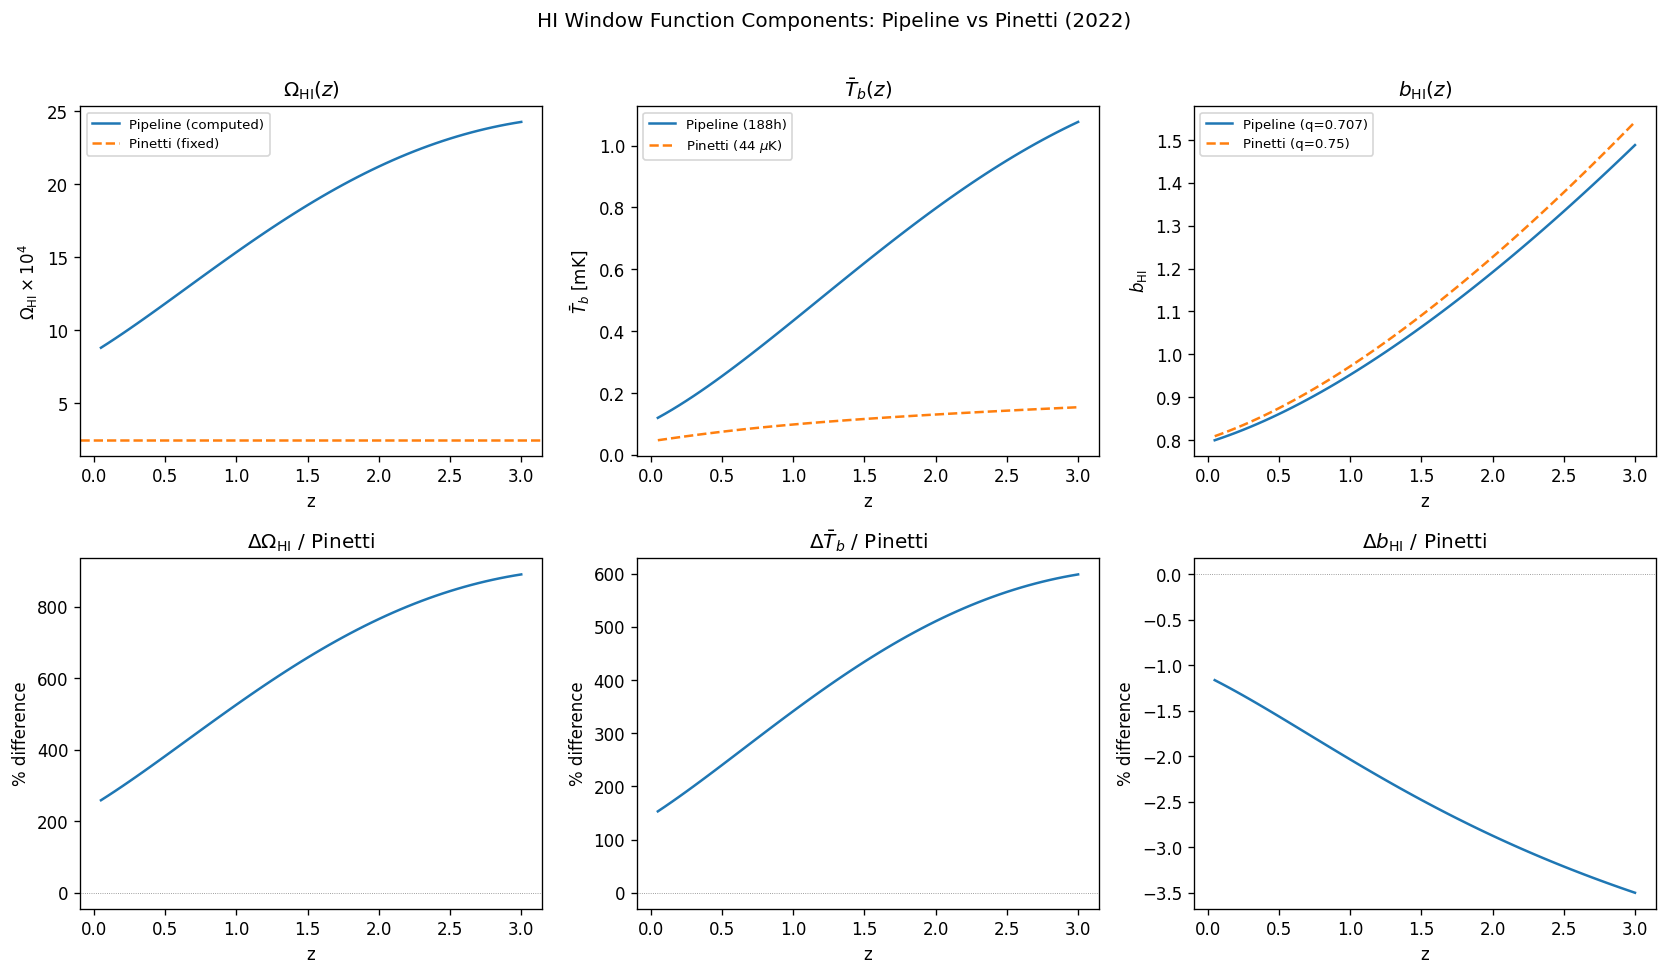

In [3]:
z_arr = np.linspace(0.05, 3.0, 60)

# Pipeline values
omega_pipe   = np.array([hi.Omega_HI(z) for z in z_arr])
Tb_pipe      = np.array([hi.T_bar_b(z) for z in z_arr])
bHI_pipe     = np.array([hi.b_HI(z) for z in z_arr])

# Pinetti (2022) values — from module
omega_pin    = np.full_like(z_arr, p22.PINETTI_OMEGA_HI)
Tb_pin       = np.array([p22.T_bar_b_thesis(z) for z in z_arr])
bHI_pin      = np.array([p22.b_HI_pinetti(z) for z in z_arr])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Row 1: absolute values
ax = axes[0, 0]
ax.plot(z_arr, omega_pipe * 1e4, 'C0-', label='Pipeline (computed)')
ax.axhline(p22.PINETTI_OMEGA_HI * 1e4, color='C1', ls='--', label='Pinetti (fixed)')
ax.set_ylabel(r'$\Omega_\mathrm{HI} \times 10^4$')
ax.set_xlabel('z')
ax.legend(fontsize=8)
ax.set_title(r'$\Omega_\mathrm{HI}(z)$')

ax = axes[0, 1]
ax.plot(z_arr, Tb_pipe, 'C0-', label='Pipeline (188h)')
ax.plot(z_arr, Tb_pin, 'C1--', label=r'Pinetti (44 $\mu$K)')
ax.set_ylabel(r'$\bar{T}_b$ [mK]')
ax.set_xlabel('z')
ax.legend(fontsize=8)
ax.set_title(r'$\bar{T}_b(z)$')

ax = axes[0, 2]
ax.plot(z_arr, bHI_pipe, 'C0-', label='Pipeline (q=0.707)')
ax.plot(z_arr, bHI_pin, 'C1--', label='Pinetti (q=0.75)')
ax.set_ylabel(r'$b_\mathrm{HI}$')
ax.set_xlabel('z')
ax.legend(fontsize=8)
ax.set_title(r'$b_\mathrm{HI}(z)$')

# Row 2: fractional differences
ax = axes[1, 0]
ax.plot(z_arr, (omega_pipe - p22.PINETTI_OMEGA_HI) / p22.PINETTI_OMEGA_HI * 100, 'C0-')
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_ylabel('% difference')
ax.set_xlabel('z')
ax.set_title(r'$\Delta\Omega_\mathrm{HI}$ / Pinetti')

ax = axes[1, 1]
ax.plot(z_arr, (Tb_pipe - Tb_pin) / Tb_pin * 100, 'C0-')
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_ylabel('% difference')
ax.set_xlabel('z')
ax.set_title(r'$\Delta\bar{T}_b$ / Pinetti')

ax = axes[1, 2]
ax.plot(z_arr, (bHI_pipe - bHI_pin) / bHI_pin * 100, 'C0-')
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_ylabel('% difference')
ax.set_xlabel('z')
ax.set_title(r'$\Delta b_\mathrm{HI}$ / Pinetti')

fig.suptitle('HI Window Function Components: Pipeline vs Pinetti (2022)', fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 2. Full Window Function Comparison

Compare the complete $W_\text{HI}(\chi)$ for ($z \in [0.0, 5.0]$).

In [ ]:

z_min, z_max = 0.0, 2.5
z_w = np.linspace(z_min + 0.01, z_max - 0.01, 80)
dz = z_w[1] - z_w[0]
c_h_over_H = np.array([cfg.C_LIGHT_KM_S * cfg.h / cosmo.H(z) for z in z_w])

# Pipeline: use normalized_windows for consistent normalization
W_pipe_norm = ap.normalized_windows(z_w, z_min_hi=z_min, z_max_hi=z_max,
                                    source_classes=[], include_DM=False)

# Pinetti: per-z conversion + same normalization convention (from module)
W_pin_perz = np.array([p22.W_HI_pinetti(z, z_min, z_max) for z in z_w]) * c_h_over_H
I_pin = np.sum(W_pin_perz) * dz
W_pin_norm = W_pin_perz / I_pin if I_pin > 0 else np.zeros_like(z_w)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(z_w, W_pipe_norm['HI'], 'C0-', lw=2, label='Pipeline')
ax1.plot(z_w, W_pin_norm, 'C1--', lw=2, label='Pinetti (2022)')
ax1.set_xlabel('z')
ax1.set_ylabel(r'$\frac{c}{H}\,W_\mathrm{HI}^{(\chi)}\;/\;\langle I_\mathrm{HI} \rangle$')
ax1.set_title('Normalized HI Window')
ax1.legend()

mask = W_pin_norm > 0
frac_diff = np.full_like(z_w, np.nan)
frac_diff[mask] = (W_pipe_norm['HI'][mask] - W_pin_norm[mask]) / W_pin_norm[mask] * 100
ax2.plot(z_w[mask], frac_diff[mask], 'C0-', lw=2)
ax2.axhline(0, color='gray', ls=':', lw=0.5)
ax2.set_xlabel('z')
ax2.set_ylabel('% difference')
ax2.set_title('(Pipeline - Pinetti) / Pinetti')

fig.tight_layout()
plt.show()

# Summary statistics
valid = frac_diff[~np.isnan(frac_diff)]
print(f"Mean |fractional difference|: {np.mean(np.abs(valid)):.1f}%")
print(f"Max  |fractional difference|: {np.max(np.abs(valid)):.1f}%")

## 3. Concentration Comparison: Pipeline (Planck B1) vs Thesis Fit

Compare $c_{200}(M,z)$ between the pipeline's Correa Planck Appendix B1 coefficients and the thesis-specific fit.

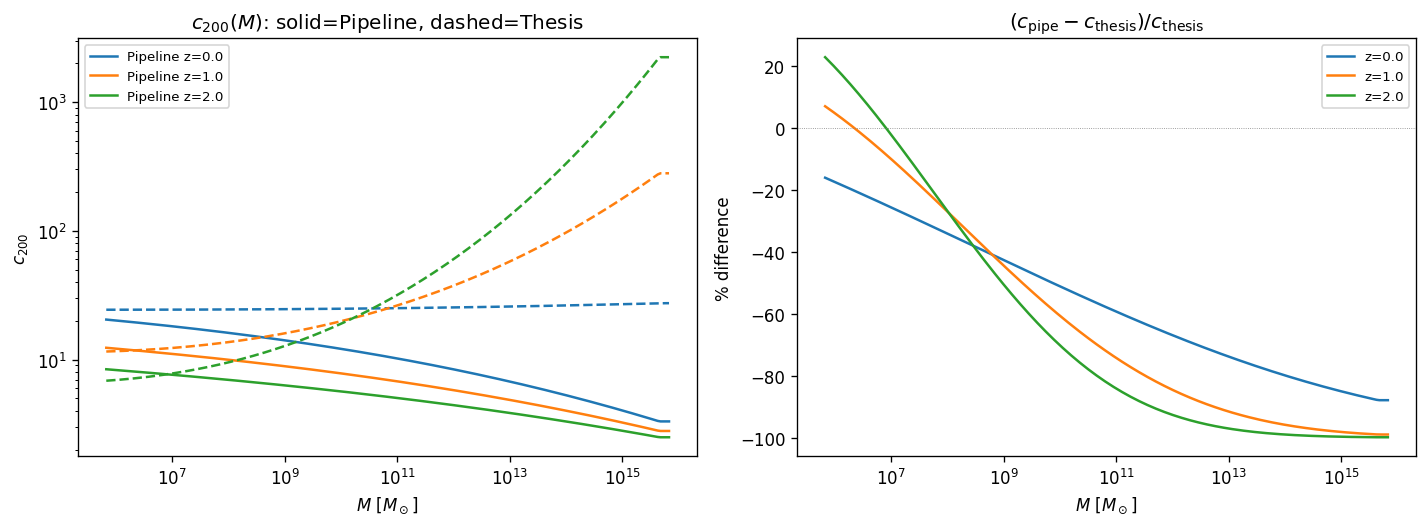

In [5]:
M_arr = np.logspace(6, 16, 200)  # M_sun/h

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for z, color in [(0.0, 'C0'), (1.0, 'C1'), (2.0, 'C2')]:
    c_pipe = hm.concentration_correa(M_arr, z)
    c_thesis = p22.concentration_correa_thesis(M_arr, z)

    ax1.loglog(M_arr * cfg.h, c_pipe, color=color, ls='-', label=f'Pipeline z={z}')
    ax1.loglog(M_arr * cfg.h, c_thesis, color=color, ls='--')

    frac = (c_pipe - c_thesis) / c_thesis * 100
    ax2.semilogx(M_arr * cfg.h, frac, color=color, label=f'z={z}')

ax1.set_xlabel(r'$M$ [$M_\odot$]')
ax1.set_ylabel(r'$c_{200}$')
ax1.set_title(r'$c_{200}(M)$: solid=Pipeline, dashed=Thesis')
ax1.legend(fontsize=8)

ax2.axhline(0, color='gray', ls=':', lw=0.5)
ax2.set_xlabel(r'$M$ [$M_\odot$]')
ax2.set_ylabel('% difference')
ax2.set_title(r'$(c_\mathrm{pipe} - c_\mathrm{thesis}) / c_\mathrm{thesis}$')
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 4. Limber $k$-Substitution Comparison

Compare $k = \ell/\chi$ (thesis) vs $k = (\ell+1/2)/\chi$ (pipeline) at low $\ell$.

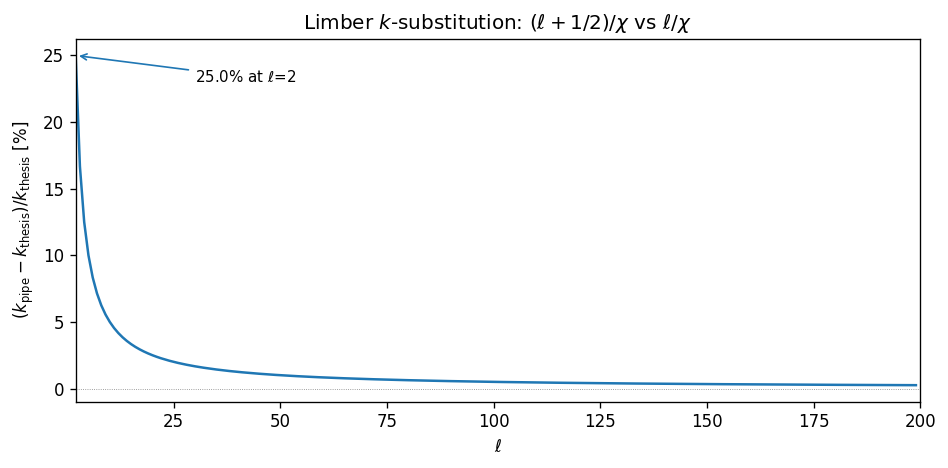

Fractional difference at ell=10: 5.0%
Fractional difference at ell=100: 0.50%


In [6]:
ell_arr = np.arange(2, 200)
chi_ref = cosmo.chi(0.8)  # Mpc/h, mid-band for MeerKAT UHF

k_pipeline = (ell_arr + 0.5) / chi_ref  # LoVerde & Afshordi (2008)
k_thesis   = ell_arr / chi_ref           # standard Limber

frac_k = (k_pipeline - k_thesis) / k_thesis * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ell_arr, frac_k, 'C0-', lw=1.5)
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$(k_\mathrm{pipe} - k_\mathrm{thesis}) / k_\mathrm{thesis}$ [%]')
ax.set_title(r'Limber $k$-substitution: $(\ell+1/2)/\chi$ vs $\ell/\chi$')
ax.set_xlim(2, 200)
ax.annotate(f'{frac_k[0]:.1f}% at $\\ell$=2', xy=(2, frac_k[0]),
            xytext=(30, frac_k[0]-2), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='C0'))
fig.tight_layout()
plt.show()

print(f"Fractional difference at ell=10: {frac_k[8]:.1f}%")
print(f"Fractional difference at ell=100: {frac_k[98]:.2f}%")

## 5. Summary Table

Quantify the impact of each individual deviation on $W_\text{HI}$ at a representative redshift.

In [ ]:
z_ref = 0.8
z_min, z_max = 0.0, 2.5

# Full pipeline W_HI
W_full_pipe = hi.W_HI(z_ref, z_min, z_max)

# Full Pinetti W_HI (from module)
W_full_pin = p22.W_HI_pinetti(z_ref, z_min, z_max)

# --- Isolate each deviation ---
H_over_ch = cosmo.H(z_ref) / (cfg.C_LIGHT_KM_S * cfg.h)
phi = 1.0 / (z_max - z_min)

# (a) Only swap T_b: use thesis T_b with pipeline b_HI
W_swap_Tb = p22.T_bar_b_thesis(z_ref) * hi.b_HI(z_ref) * phi * H_over_ch

# (b) Only swap bias: use pipeline T_b with thesis b_HI
W_swap_b = hi.T_bar_b(z_ref) * p22.b_HI_pinetti(z_ref) * phi * H_over_ch

print(f"Reference redshift: z = {z_ref}")
print(f"{'='*60}")
print(f"{'Component':<35} {'W_HI':>12}  {'vs Pinetti':>10}")
print(f"{'-'*60}")
print(f"{'Pipeline (all pipeline choices)':<35} {W_full_pipe:>12.6f}  {'---':>10}")
print(f"{'Pinetti (all thesis choices)':<35} {W_full_pin:>12.6f}  {'ref':>10}")
print(f"{'Swap only T_b -> thesis 44 muK':<35} {W_swap_Tb:>12.6f}  {(W_swap_Tb/W_full_pin - 1)*100:>+9.1f}%")
print(f"{'Swap only b_HI -> thesis q=0.75':<35} {W_swap_b:>12.6f}  {(W_swap_b/W_full_pin - 1)*100:>+9.1f}%")
print(f"{'-'*60}")
print(f"{'Combined difference':<35} {'':>12}  {(W_full_pipe/W_full_pin - 1)*100:>+9.1f}%")
print()
print("Note: Correa concentration (item 4) does not affect W_HI directly;")
print("      it only enters via the DM NFW profile in the cross-power spectrum.")
print("      Limber k-substitution (item 5) affects C_ell, not W_HI itself.")